<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_week6_2_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###딥러닝 파이토치
p166~179

#5. 합성곱 신경망 1
## 5.1 합성곱 신경망
**5.1.1 합성곱층의 필요성**

> 딥러닝의 역전파에서 순전파의 오차정보를 신경망의 모든 노드로 전송하여 계산하는 과정을 거쳤었다. 복잡성, 자원 문제가 발생하여 합성곱 신경망으로 해결하고자한다. 이미지의 국소적 부분을 계산함으로써 시간과 자원 절약하고 세밀하게 분석할수있다.

**5.1.2 합성곱 신경망 구조**
- 합성곱 신경망 : 음성인식이나 이미지/영상인식에서 사용되며 다차원 배열 데이터를 처리하도록 구성되어있다.
- 계층 : 합성곱층과 풀링층을 거치면서 입력이미지의 주요특성벡터를 추출한다. 이것들은 완전 연결층을 거치면서 1차원 벡터로 변환되며 마지막에 소프트맥스함수를 사용하여 최종결과가 출력된다.

  1. 입력층 : 높이, 너비, 채널 (W x H x D)값을 갖는 3차원 데이터
    - 이미지가 gray scale이면 채널 1, RGB이면 채널 3 값을 가짐
  2. 합성곱층 : 입력 데이터에서 특성 추출역할 수행
    - 특성 추출 : 커널, 필터를 사용함, 이미지의 모든 영역을 훑으면서 추출한 결과물이 특성 맵이다.
    - 커널은 3x3, 5x5 크기, 스트라이드 간격에 따라 이동함
    - 줄어든 크기의 특성맵이 만들어지기도 함
    - 컬러 이미지의 합성곱 : 필터 채널이 3개이다. RGB 각각에 다른 가중치로 합성곱 적용 후 결과를 더해준다. (필터 개수는 1개이다.)
    - 입력데이터 (W1 x H1 x D1)
    - 하이퍼파라미터
      - 필터 개수 K
      - 필터 크기 F
      - 스트라이드 S
      - 패딩 P
    - 출력 데이터
      - W2= (W-F+2P)/S +1
      - H2= (H1-F+2P)/S +1
      - D2= K
  3. 풀링층 : 특성 맵의 차원을 다운샘플링하여 연산량을 감소시킴, 특성 벡터 추출하여 학습시킴
  - 최대 풀링 VS 평균 풀링 -> 대부분 최대풀링 사용됨
  - 출력 데이터
    - W2= (W1-F)/S +1
    - H2= (H1-F)/S +1
    - D2= D1
  4. 완전연결층 : 3차원 벡터에서 1차원 벡터로 펼쳐짐

  5. 출력층 : 소프트맥스 활성화함수 사용하여 입력값을 0~1로 출력, 이미지가 각 레이블에 속할 확률값이 출력되며 가장 높은 값의 레이블이 선정된다.

**5.1.3 1D, 2D, 3D 합성곱**
> 1D 합성곱 : 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱, 그래프 곡선 완화 시 사용
> - 입력W 와 필터k에 대한 출력은 W가 됨
>    - Ex) 입력 [1,1,1,1], 필터 [0.25, 0.75] -> 출력 [1,1,1] 1D 배열

> 2D 합성곱 : 필터가 방향 두 개로 움직이는 형태, 입력 (W, H)과 필터 (k, k) -> 출력 (W, H) 2D 행렬
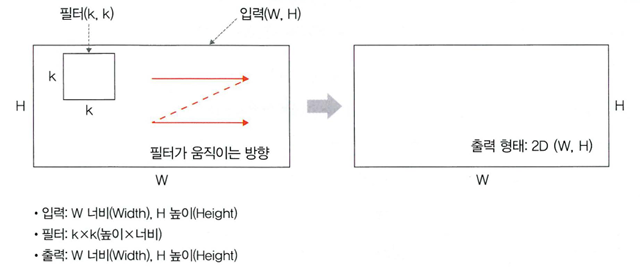


> 3D 합성곱 : 필터 움직이는 방향이 3개 있음, 입력(W, H, L)에 필터(k, k, d) -> 출력 (W, H, L) 3D 형태 **d<L

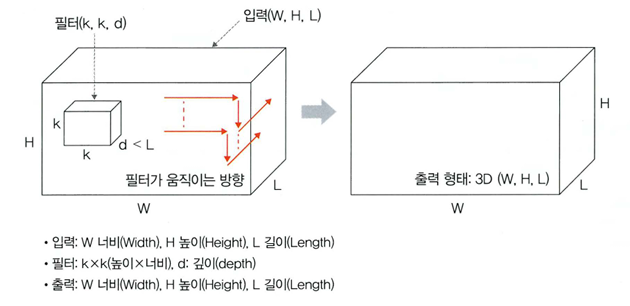

> 3D 입력을 갖는 2D 합성곱 : 2D 행렬로 출력되는 것
- 필터에 대한 길이 L 이 입력 채널의 길이 L 과 같아야하기 때문에 이와같은 합성곱 형태 만들어짐 -> 필터가 전체 채널길이랑 똑같으니까 2D로 출력되는것
- 입력 (W, H, L)에 필터 (k, k, L) -> 출력 (W, H) 2D 행렬
- 필터는 두 방향으로 움직임
- Ex) LeNet-5, VGG
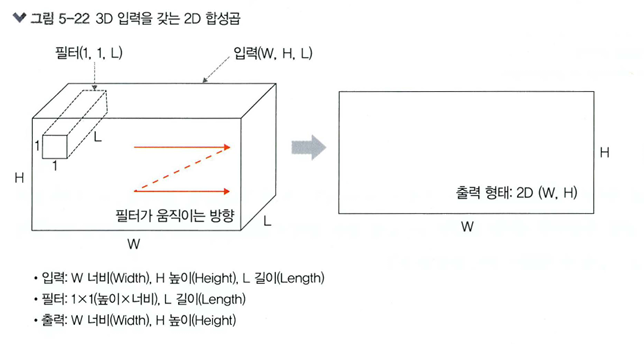

> 1x1 합성곱 : 3D 형태로 입력됨
- 입력(W, H, L)에 필터(1, 1, L) -> 출력(W, H)
- 채널 수를 조정해서 연산량이 감소되는 효과가 있음
- Ex) GoogLeNet
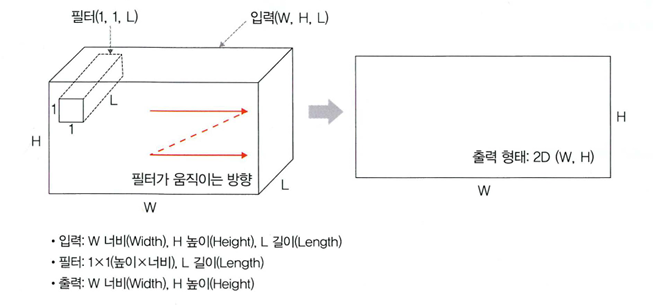
